# Binary Image Classifier: Open Mouth vs Closed Mouth

This notebook trains a binary image classifier using **MobileNetV2** with transfer learning to distinguish between **open mouth** and **closed mouth** images.

### Pipeline Overview
1. Install & import dependencies
2. Load and augment the dataset
3. Build the model (MobileNetV2 + custom head)
4. Compile the model
5. Train for 15 epochs
6. Plot accuracy & loss curves
7. Export the model to TensorFlow.js format

## 1. Install & Import Dependencies

We install `tensorflowjs` (needed later for export) and import TensorFlow / Keras, Matplotlib, and OS utilities.

In [25]:
%pip install tensorflowjs --quiet

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.16.1
GPU available: []



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load & Augment the Dataset

The dataset is stored under `training/dataset/` with two sub-folders:
- `open_mouth/`
- `closed_mouth/`

We use `ImageDataGenerator` to apply data augmentation on the training split:
- **Rescale** pixel values to [0, 1]
- **Rotation** up to 20°
- **Zoom** up to 20%
- **Horizontal flip**

A validation split of 20% is reserved for evaluation.

In [26]:
# ----- Configuration -----
DATASET_DIR = os.path.join('training', 'dataset')
IMG_SIZE = (224, 224)
NUM_CLASSES = 2
EPOCHS = 15

# Count total images to decide batch size and validation strategy
total_images = sum(
    len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for _, _, files in os.walk(DATASET_DIR)
)
print(f"Total images found: {total_images}")

# For tiny datasets: no validation split, batch size = 1
# For normal datasets (50+): use 80/20 split, batch size = 32
USE_VAL_SPLIT = total_images >= 20
BATCH_SIZE = min(32, max(1, total_images // 4))

print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {'20%' if USE_VAL_SPLIT else 'None (dataset too small, using training data for both)'}")

if USE_VAL_SPLIT:
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
    )
    train_generator = train_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training', shuffle=True
    )
    val_generator = train_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation', shuffle=False
    )
else:
    # Tiny dataset — use augmented data for training, raw data for "validation"
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )
    val_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_generator = train_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True
    )
    val_generator = val_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False
    )

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Total images found: 7
Batch size: 1
Validation split: None (dataset too small, using training data for both)
Found 7 images belonging to 2 classes.
Found 7 images belonging to 2 classes.

Class indices: {'closed_mouth': 0, 'open_mouth': 1}
Training samples: 7
Validation samples: 7


## 3. Build the Model

We use **MobileNetV2** pre-trained on ImageNet as the feature extractor (base). The base layers are frozen so only the new classification head is trained.

**Architecture:**
- MobileNetV2 base (frozen)
- Global Average Pooling
- Dropout (0.3) for regularisation
- Dense layer with 128 units + ReLU
- Output Dense layer with 2 units + **softmax**

In [27]:
# ----- Load pre-trained MobileNetV2 (exclude top) -----
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model layers
base_model.trainable = False

# ----- Add custom classification head -----
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Compile the Model

We compile with:
- **Optimizer:** Adam (learning rate 1e-3)
- **Loss:** Categorical Cross-Entropy (2 classes)
- **Metric:** Accuracy

In [21]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


## 5. Train the Model

Train for **15 epochs** using the augmented training set and validate on the held-out 20% split.

In [30]:
# Ensure model is compiled before training
if not hasattr(model, 'optimizer') or model.optimizer is None:
    print("Model was not compiled — compiling now...")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

print("\nTraining complete.")

Model was not compiled — compiling now...
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 625ms/step - accuracy: 0.4286 - loss: 2.3755 - val_accuracy: 0.7143 - val_loss: 0.7099
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5714 - loss: 0.6502 - val_accuracy: 0.5714 - val_loss: 0.6315
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.8571 - loss: 0.4092 - val_accuracy: 0.8571 - val_loss: 0.2636
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 - loss: 0.1792 - val_accuracy: 1.0000 - val_loss: 0.0555
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 1.0000 - loss: 0.1043 - val_accuracy: 1.0000 - val_loss: 0.0270
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 1.0000 - val_loss: 0.0195
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 1.0000 - loss: 0.0720 - val_accuracy: 1.0000 - val_loss: 0.0194
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 1.0000 - loss

## 6. Plot Accuracy & Loss Curves

Visualise how accuracy and loss evolve over the 15 epochs for both training and validation sets. This helps diagnose overfitting or underfitting.

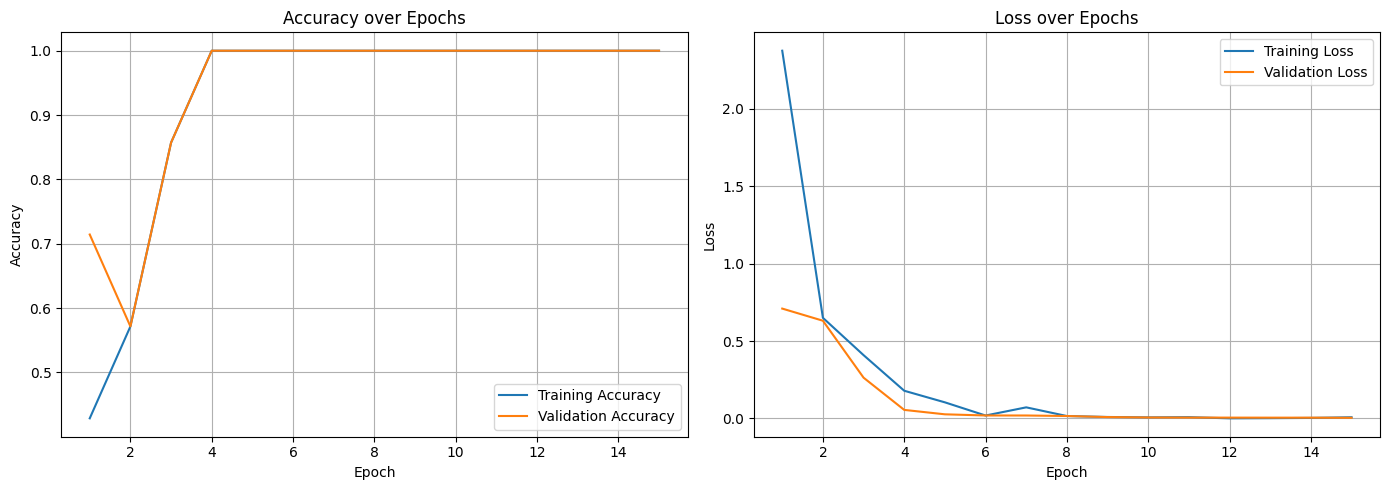


Final training accuracy: 1.0000
Final validation accuracy: 1.0000


In [31]:
history_obj = globals().get('history', None)

if history_obj is None:
    print("No training history found. Run the training cell first to create 'history'.")
else:
    history_dict = getattr(history_obj, 'history', {})
    acc = history_dict.get('accuracy', [])
    val_acc = history_dict.get('val_accuracy', [])
    loss = history_dict.get('loss', [])
    val_loss = history_dict.get('val_loss', [])

    if not acc:
        print("Training ran, but no accuracy values were found in history.")
    else:
        epochs_range = range(1, len(acc) + 1)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # --- Accuracy ---
        ax1.plot(epochs_range, acc, label='Training Accuracy')
        if val_acc:
            ax1.plot(epochs_range, val_acc, label='Validation Accuracy')
        ax1.set_title('Accuracy over Epochs')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True)

        # --- Loss ---
        ax2.plot(epochs_range, loss, label='Training Loss')
        if val_loss:
            ax2.plot(epochs_range, val_loss, label='Validation Loss')
        ax2.set_title('Loss over Epochs')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        print(f"\nFinal training accuracy: {acc[-1]:.4f}")
        if val_acc:
            print(f"Final validation accuracy: {val_acc[-1]:.4f}")

## 7. Export Model to TensorFlow.js

First we save the Keras model to a temporary directory, then convert it to **TensorFlow.js** format inside `model_export/`. This allows the model to be loaded directly in a browser or Node.js application.

In [32]:
import subprocess

EXPORT_DIR = 'model_export'
SAVED_MODEL_DIR = 'saved_model_temp'
os.makedirs(EXPORT_DIR, exist_ok=True)

# Step 1: Save the Keras model in SavedModel format
model.export(SAVED_MODEL_DIR)
print(f"Keras model saved to '{SAVED_MODEL_DIR}/'")

# Step 2: Convert to TensorFlow.js using command-line tool (avoids import bug)
result = subprocess.run(
    [
        'tensorflowjs_converter',
        '--input_format=tf_saved_model',
        '--output_format=tfjs_graph_model',
        SAVED_MODEL_DIR,
        EXPORT_DIR
    ],
    capture_output=True, text=True
)

if result.returncode == 0:
    print(f"\nModel exported to '{EXPORT_DIR}/' successfully.")
    print("Contents:")
    for f in os.listdir(EXPORT_DIR):
        print(f"  {f}")
else:
    print("Export failed:")
    print(result.stderr)

INFO:tensorflow:Assets written to: saved_model_temp\assets


INFO:tensorflow:Assets written to: saved_model_temp\assets


Saved artifact at 'saved_model_temp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_642')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2824437613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437613584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824383904272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437625872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437614352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437617040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437614160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437613776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437619728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437615120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2824437612816: TensorSpec(shap

## Done!

The trained model has been exported to `model_export/`. You can now load it in a web application using:

```js
const model = await tf.loadLayersModel('model_export/model.json');
```

**Class mapping:**
- `0` → `closed_mouth`
- `1` → `open_mouth`

*(Verify the exact indices printed in Step 2 — they depend on alphabetical folder order.)*